# Solución con LangGraph

V 1.0

* Estado:

## conexiones a base de datos y demases que se ejecutan al inicio

In [1]:
# --- Conexión a MongoDB Atlas ---
from pymongo import MongoClient
from dotenv import load_dotenv
import os

load_dotenv()

# URI definida en .env
uri = os.getenv("URI_mia")   # o el nombre que uses
print("URI cargada:", bool(uri))

# Cliente de Mongo
client = MongoClient(uri)

# Base de datos y colección
db = client["catalogo_repuestos"]
coleccion = db["repuestos_internos"]

# Test
try:
    client.admin.command("ping")
    print("✅ Conexión a MongoDB Atlas exitosa.")
except Exception as e:
    print("❌ Error de conexión:", e)

print("Colección lista:", coleccion.full_name)


URI cargada: True
✅ Conexión a MongoDB Atlas exitosa.
Colección lista: catalogo_repuestos.repuestos_internos


In [2]:
from langchain_huggingface import HuggingFaceEmbeddings

embedder = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)


/home/nicolas/entornos/trabajo-final-modulo6_python3.11.13/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from langchain_groq import ChatGroq
import os

# Definí directamente el modelo de Groq:
llm_model = "llama-3.1-8b-instant"   # también podés usar "llama3-70b-8192"
print(llm_model)

# Creá el LLM con tu API key ya cargada en el entorno
llm = ChatGroq(model=llm_model, temperature=0.1)

# Probá una consulta
response = llm.invoke("¿por qué motivo un pobre puede votar un candidato de derecha?")
print(response.text)

llama-3.1-8b-instant
Hay varias razones por las que un pobre puede votar a un candidato de derecha, a pesar de que los programas de derecha a menudo se asocian con políticas que pueden beneficiar a los ricos y no necesariamente a los pobres. Algunas de estas razones incluyen:

1. **Identidad política**: La identidad política de una persona puede ser más fuerte que sus intereses económicos. Un pobre puede identificarse con los valores y principios de un partido de derecha, como la libertad individual, la propiedad privada o la religión, y puede sentir que estos valores se alinean con sus creencias personales.
2. **Miedo a la inseguridad**: Los pobres pueden sentirse inseguros sobre su futuro y su bienestar, y pueden creer que un gobierno de derecha puede proporcionarles más seguridad y estabilidad. Esto puede ser especialmente cierto en países con altos niveles de delincuencia o inestabilidad política.
3. **Falta de acceso a la información**: Los pobres pueden tener menos acceso a la in

## Descripción del flujo de trabajo propuesto

### 🔷 ETAPA 1
Ingreso + validación de marca/modelo

Flujo esperado:

Usuario:
“tengo un Toyota Etios”

LLM → extrae (marca_vehiculo: "Toyota", modelo: "Etios")

Python verifica que existe en la base:
* Si existe: continuar

* Si NO existe: LLM: “No tengo ese modelo. ¿Querés intentar otra descripción o verificar el año?”

### 🔷 ETAPA 2 — Ingreso de repuestos (loop)

*Objetivo:* Permitir al usuario ingresar 1 repuesto, sugerirle 1–5 opciones, permitir elegir, y luego preguntar: “¿Querés agregar otro repuesto? (sí/no)”

Esto forma un ciclo:

INGRESA DESCRIPCIÓN --> BUSCA --> MUESTRA --> CONFIRMA --> AGREGA AL PEDIDO --> ¿AGREGAR OTRO? --> LOOP


### 🔷 ETAPA 3,4,5...N

va todo lo demás....

# Posible implementación con LangGraph

## Estado

Acá se define el estado del grafo

In [4]:
from typing import TypedDict, List, Optional, Literal


class Vehiculo(TypedDict, total=False):
    marca: Optional[str]
    modelo: Optional[str]


class ItemRepuesto(TypedDict, total=False):
    descripcion: str
    marca_repuesto: str
    marca_vehiculo: str
    modelo: str
    anio: str
    precio: float
    stock: int
    score: float


class State(TypedDict, total=False):
    vehiculo: Vehiculo
    items: List[ItemRepuesto]
    descripcion_actual: Optional[str]
    candidatos: List[ItemRepuesto]
    sigue_buscando: Optional[bool]


## Nodos

### 1️⃣ Primer nodo: nodo_obtener_vehiculo

Este nodo:

* pide marca y modelo (por ahora con input, luego LLM),

* valida contra la colección,

* si está ok, setea vehiculo y pasa a la búsqueda de repuestos.

In [5]:
def validar_marca_modelo(marca: str, modelo: str, coleccion) -> bool:
    """ Esta función verifica si la marca y el modelo existen en la colección dada. """
    marcas = coleccion.distinct("Marca Vehículo")
    if marca not in marcas:
        return False

    modelos = coleccion.distinct("Modelo")
    if modelo not in modelos:
        return False

    return True


In [17]:
def nodo_obtener_vehiculo(state: State) -> State:
    """
    Nodo que solicita la marca y el modelo del vehículo al usuario.
    Si la combinación es válida, actualiza el estado con el vehículo.
    Si no lo es, guarda el intento y deja vehiculo=None para que el router
    envíe a desambiguar_vehiculo.
    """
    marca = input("Marca del vehículo: ").strip()
    modelo = input("Modelo del vehículo: ").strip()

    # guardamos el intento para usarlo después en desambiguar_vehiculo
    partial = {
        "marca_intento": marca,
        "modelo_intento": modelo,
    }

    # validación contra Mongo
    if not validar_marca_modelo(marca, modelo, coleccion):
        print("❌ Vehículo no encontrado en la base.\n")
        # señalamos explícitamente que NO tenemos vehículo válido
        partial["vehiculo"] = None
        return { **state, **partial }

    # si llegamos acá, es válido
    print(f"✅ Vehículo reconocido: {marca} {modelo}\n")

    partial["vehiculo"] = {
        "marca": marca,
        "modelo": modelo
    }

    return { **state, **partial }


In [16]:
def ex_nodo_obtener_vehiculo(state: State) -> State:
    """Este nodo se ocupa de solicitar al usuario la marca y el modelo del vehículo,
    y de validar que existan en la colección dada. Si son válidos, actualiza el estado
    con la información del vehículo y avanza a la siguiente etapa."""
    # Pedimos datos al usuario (por ahora via input)
    marca = input("Marca del vehículo: ").strip()
    modelo = input("Modelo del vehículo: ").strip()

    if not validar_marca_modelo(marca, modelo, coleccion):
        print("❌ Vehículo no encontrado en la base. Probá de nuevo.\n")
        # Volvemos a la misma etapa
        return {
            **state
        }

    print(f"✅ Vehículo reconocido: {marca} {modelo}\n")

    # Devolvemos un nuevo estado actualizado
    return {
        **state,
        "vehiculo": {"marca": marca, "modelo": modelo}
    }


### 1️⃣🅱️ DESAMBIGÜAR vehículo

In [28]:
import re
from typing import List, Dict, Any

def modelos_similares(marca, modelo, coleccion) -> List[Dict[str, Any]]:
    """
    Devuelve una lista de documentos de posibles vehículos similares
    a partir de la marca y el modelo ingresados por el usuario.

    - Normaliza marca y modelo a strings.
    - Usa búsquedas con $regex case-insensitive.
    - Primero intenta marca + modelo.
    - Si no hay resultados, intenta solo por marca.
    - Si aún no hay resultados, intenta solo por modelo.
    """

    # Normalizar y asegurar que sean strings
    marca = (marca or "").strip()
    modelo = (modelo or "").strip()

    if not isinstance(marca, str):
        marca = str(marca)
    if not isinstance(modelo, str):
        modelo = str(modelo)

    # Escapamos para que el input del usuario no rompa el regex
    marca_regex = re.escape(marca)
    modelo_regex = re.escape(modelo)

    proyeccion = {
        "Marca Vehículo": 1,
        "Modelo": 1,
        "Año": 1,
        "_id": 0,
    }

    # 1) Marca + modelo parecidos
    filtro = {
        "Marca Vehículo": {"$regex": marca_regex, "$options": "i"},
        "Modelo": {"$regex": modelo_regex, "$options": "i"},
    }
    sugerencias = list(coleccion.find(filtro, proyeccion).limit(10))
    if sugerencias:
        return sugerencias

    # 2) Solo marca
    if marca:
        filtro = {
            "Marca Vehículo": {"$regex": marca_regex, "$options": "i"},
        }
        sugerencias = list(coleccion.find(filtro, proyeccion).limit(10))
        if sugerencias:
            return sugerencias

    # 3) Solo modelo
    if modelo:
        filtro = {
            "Modelo": {"$regex": modelo_regex, "$options": "i"},
        }
        sugerencias = list(coleccion.find(filtro, proyeccion).limit(10))
        if sugerencias:
            return sugerencias

    # Si nada matchea, devolvemos lista vacía
    return []


In [32]:
def nodo_desambiguar_vehiculo(state: State) -> State:
    marca = state.get("marca_intento")
    modelo = state.get("modelo_intento")

    sugerencias = modelos_similares(marca, modelo, coleccion)

    prompt = f"""
El usuario ingresó un vehículo que no se encontró en la base de datos:

Marca ingresada: "{marca}"
Modelo ingresado: "{modelo}"

Opciones similares encontradas en la base:
{sugerencias}

Tu tarea:
- Explicá de forma breve y amable que no encontramos esa combinación.
- Mostrá las opciones más probables.
- Preguntale al usuario cuál de estas opciones corresponde a su vehículo.
"""

    respuesta = llm.invoke(prompt)

    # 👉 LO QUE TE FALTABA
    print("\n")
    print("🛈 Sugerencias del sistema para ayudarte:")
    print(respuesta)
    print("\n")
    return {
        "descripcion_actual": respuesta,
        "vehiculo": None
    }


### 2️⃣ Segundo nodo: nodo_buscar_repuesto

Este nodo:

* Pide una descripción de repuesto (por ahora input).

* Llama a buscar_semantico_filtrado.

* Filtra con filtrar_por_score_relativo.

* Guarda:

    > descripcion_actual

    > candidatos

    > etapa="confirmando_item"

In [20]:
def buscar_semantico_filtrado(marca_vehiculo, modelo, descripcion, n=5):
    """Esta función realiza una búsqueda semántica en la colección,
    filtrando por marca, modelo del vehículo. Devuelve hasta n resultados."""
    
    # 1) Vectorizamos SOLO la descripción
    query_vector = embedder.embed_query(descripcion)

    # 2) Armamos la query con filtro estructurado
    pipeline = [
        {
            "$vectorSearch": {
                "index": "vector_index",
                "path": "embedding",
                "queryVector": query_vector,
                "numCandidates": 100,
                "limit": n,
                "filter": {
                    "Marca Vehículo": marca_vehiculo,
                    "Modelo": modelo#,
                    # si Año es texto tipo "2006-2012", jugamos con regex
                    #"Año": {"$regex": str(anio)}
                }
            }
        },
        ## entiendo que esta parte es opcional,
        # Acá se genera "el documento que se devuelve"... podríamos omitir
        # campos (por en este caso _id)
        {
            "$project": {
                "_id": 0,
                "Descripción": 1,
                "Marca": 1,
                "Marca Vehículo": 1,
                "Modelo": 1,
                "Año": 1,
                "Precio": 1,
                "Stock": 1,
                "score": {"$meta": "vectorSearchScore"}
            }
        }
    ]

    return list(coleccion.aggregate(pipeline))


In [21]:
def filtrar_por_score_relativo(resultados, min_abs=0.6, factor_rel=0.9):
    """
    esta función filtra una lista de resultados basada en su score relativo y absoluto.
    Parámetros:
    - min_abs: score mínimo absoluto. Por debajo de este valor, se descarta.
    - factor_rel: porcentaje del mejor score (0.9 = 90% del mejor). Los que estén por debajo de este umbral se descartan.
    Retorna la lista filtrada de resultados.
    """
    if not resultados:
        return []

    top = resultados[0]["score"]
    filtrados = []
    for r in resultados:
        if r["score"] >= min_abs and r["score"] >= top * factor_rel:
            filtrados.append(r)
    return filtrados


In [22]:
def nodo_buscar_repuesto(state: State) -> State:
    vehiculo = state.get("vehiculo", {})
    marca = vehiculo.get("marca")
    modelo = vehiculo.get("modelo")

    if not marca or not modelo:
        print("❌ No hay vehículo definido todavía.")
        return {**state}

    descripcion = input("Decime qué repuesto necesitás: ").strip()

    candidatos_brutos = buscar_semantico_filtrado(
        marca_vehiculo=marca,
        modelo=modelo,
        descripcion=descripcion,
        n=5,
    )

    candidatos_filtrados = filtrar_por_score_relativo(
        candidatos_brutos, min_abs=0.6, factor_rel=0.8
    )

    if not candidatos_filtrados:
        print("⚠️ No encontré nada suficientemente parecido a eso.\n")
        # Volvemos a pedir descripción de repuesto
        return {
            **state,
            "descripcion_actual": descripcion,
            "candidatos": []
        }

    
    #print("\nOpciones encontradas:")
    #for i, r in enumerate(candidatos_filtrados, start=1):
    #    print(
    #        f"{i}. {r['Descripción']} - {r['Marca']} "
    #        f"({r['Marca Vehículo']} {r['Modelo']} {r['Año']}) "
    #        f"- ${r['Precio']} ({r['Stock']} u.) | score={r['score']:.2f}"
    #    )
    #print()

    # Devolvemos candidatos y pasamos a etapa de confirmación
    return {
        **state,
        "descripcion_actual": descripcion,
        "candidatos": candidatos_filtrados
    }


### 3️⃣ Tercer Nodo (confirmar repuesto solicitado)

Este nodo:

Toma state["candidatos"] (llenado en nodo_buscar_repuesto).

Deja elegir uno.

Lo agrega a state["items"].

Pregunta si querés agregar otro repuesto.

Según la respuesta, deja state["etapa"] en:

"esperando_repuesto" → para seguir buscando más

"finalizado" → para cerrar el pedido

In [23]:
def nodo_confirmar_repuesto(state: State) -> State:
    
    candidatos = state.get("candidatos") or []

    if not candidatos:
        print("⚠️ No hay candidatos para confirmar. Volvemos a pedir un repuesto.\n")
        return {**state}

    # Mostrar de nuevo los candidatos (por si el usuario no recuerda)
    print("Opciones disponibles:")
    for i, r in enumerate(candidatos, start=1):
        print(
            f"{i}. {r['Descripción']} - {r['Marca']} "
            f"({r['Marca Vehículo']} {r['Modelo']} {r['Año']}) "
            f"- ${r['Precio']} ({r['Stock']} u.) | score={r['score']:.2f}"
        )

    # Pedimos que elija una opción
    while True:
        elec = input("\nElegí el número del repuesto que querés agregar al pedido (o ENTER para cancelar): ").strip()
        if elec == "":
            print("No se seleccionó ningún repuesto. Volvemos a buscar otro.\n")
            return {**state}

        if elec.isdigit():
            idx = int(elec) - 1
            if 0 <= idx < len(candidatos):
                break

        print("Entrada inválida. Elegí un número de la lista.")

    elegido = candidatos[idx]

    # Construimos un ItemRepuesto "ordenado"
    nuevo_item: ItemRepuesto = {
        "descripcion": elegido["Descripción"],
        "marca_repuesto": elegido["Marca"],
        "marca_vehiculo": elegido["Marca Vehículo"],
        "modelo": elegido["Modelo"],
        "anio": elegido["Año"],
        "precio": float(elegido["Precio"]),
        "stock": int(elegido["Stock"]),
        "score": float(elegido["score"]),
    }

    items = list(state.get("items") or [])
    items.append(nuevo_item)

    print("\n✅ Repuesto agregado al pedido:")
    print(
        f"- {nuevo_item['descripcion']} ({nuevo_item['marca_repuesto']}) "
        f"para {nuevo_item['marca_vehiculo']} {nuevo_item['modelo']} {nuevo_item['anio']} "
        f"- ${nuevo_item['precio']}"
    )

    # Preguntamos si quiere seguir agregando repuestos
    while True:
        otro = input("\n¿Querés agregar otro repuesto? (s/n): ").strip().lower()
        if otro in ("s", "n"):
            break
        print("Respondé 's' o 'n'.")

    #if otro == "s":
    #    nueva_etapa = "esperando_repuesto"
    #else:
    #    nueva_etapa = "finalizado"
    #    print("\n📦 Pedido cerrado (por ahora).")

    if otro != "s":
        print("\n📦 Pedido cerrado (por ahora).")

    # Devolvemos el nuevo estado
    return {
        **state,
        "items": items,
        "candidatos": [],
        "descripcion_actual": None,
        "sigue_buscando": otro == "s"
    }


# improviso un grafo para ir probando

In [33]:
from langgraph.graph import StateGraph, START, END

# Inicializamos el grafo indicando el tipo de estado
graph = StateGraph(State)

# -----------------------------
# 1) Agregar tus nodos
# -----------------------------
graph.add_node("obtener_vehiculo", nodo_obtener_vehiculo)
graph.add_node("buscar_repuesto", nodo_buscar_repuesto)
graph.add_node("confirmar_repuesto", nodo_confirmar_repuesto)

# 👉 este es para desambigüar la elección de marca y modelo de vehículo:
graph.add_node("desambiguar_vehiculo", nodo_desambiguar_vehiculo)


# -----------------------------
# 2) Aristas directas
# -----------------------------

# START -> obtener_vehiculo
graph.add_edge(START, "obtener_vehiculo")

# Por ahora hacemos:
# obtener_vehiculo -> buscar_repuesto
# buscar_repuesto -> END
# (después lo reemplazamos cuando agreguemos el nodo confirmar_item)
# graph.add_edge("buscar_repuesto", END)

# -----------------------------
# 3) Arista condicional después de obtener_vehiculo
# -----------------------------

def valida_veiculo_completo(state: State) -> str:
    """
    Decide a dónde ir después del nodo obtener_vehiculo.
    - Si encontró el vehículo, pasa a buscar_repuesto.
    - Si NO lo encontró, va a desambiguar_vehiculo.
    """
    vehiculo = state.get("vehiculo")
    if vehiculo and vehiculo.get("marca") and vehiculo.get("modelo"):
        return "buscar_repuesto"
    return "desambiguar_vehiculo"

graph.add_conditional_edges(
    "obtener_vehiculo",
    valida_veiculo_completo,
    {
        "buscar_repuesto": "buscar_repuesto",
        "desambiguar_vehiculo": "desambiguar_vehiculo"
    }
)

graph.add_edge("desambiguar_vehiculo", "obtener_vehiculo")

# -----------------------------
# 4) buscamos UN repuesto y vamos a confirmar_repuesto
# -----------------------------
graph.add_edge("buscar_repuesto", "confirmar_repuesto")

# TRANSICIÓN DESPUÉS DE confirmar_repuesto (es para ver si seguimos buscando más repuestos o terminamos)
def transicion_confirmar_repuesto(state: State) -> str:
    """
    Decide si volvemos a buscar otro repuesto o si terminamos.
    """
    if state.get("sigue_buscando"):
        return "otro"
    return "fin"

    #if state.get("etapa") == "esperando_repuesto":
    #    return "otro"
    # cualquier otra cosa (incluye 'finalizado') -> fin
    #return "fin"

graph.add_conditional_edges(
    "confirmar_repuesto",
    transicion_confirmar_repuesto,
    {
        "otro": "buscar_repuesto",
        "fin": END,
    },
)

# -----------------------------
# 5) Compilamos el grafo
# -----------------------------
app = graph.compile()

print("Grafo compilado con éxito.")


Grafo compilado con éxito.


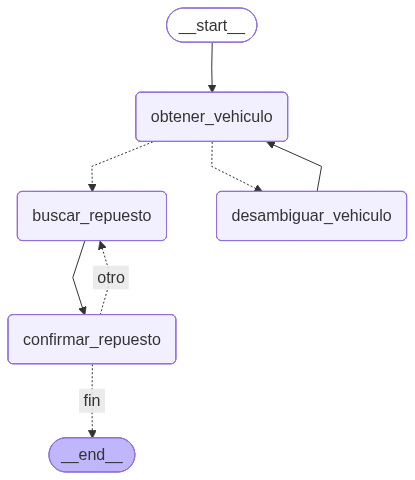

In [35]:
from IPython.display import Image, display
# retrieve the graph, draw the mermaing code, model that as an image, and display it
display(Image(app.get_graph().draw_mermaid_png(max_retries=5, retry_delay=2.0)))

In [34]:
state_inicial: State = {
    "vehiculo": {"marca": None, "modelo": None},
    "items": [],
    "descripcion_actual": None,
    "candidatos": []
}

resultado = app.invoke(state_inicial)

print("\n--- Estado final ---")
resultado

❌ Vehículo no encontrado en la base.



🛈 Sugerencias del sistema para ayudarte:
content='**No encontramos la combinación de vehículo que ingresaste**\n\nLo siento, pero no encontramos un vehículo con la marca y modelo que ingresaste en nuestra base de datos. Sin embargo, encontramos algunas opciones similares que podrían corresponder a tu vehículo.\n\n**Opciones similares encontradas:**\n\n1. Ford - Focus (2020-2024)\n2. Renault - Clio (2000-2005)\n3. Toyota - Etios (2013-2020)\n4. Chevrolet - Corsa (2006-2012)\n5. Chevrolet - Cruze (2000-2005)\n6. Ford - Fiesta (2000-2005)\n7. Ford - Fiesta (2013-2020)\n8. Chevrolet - Cruze (2000-2005)\n9. Ford - Fiesta (2013-2020)\n10. Fiat - Uno (2006-2012)\n\n**¿Cuál de estas opciones corresponde a tu vehículo?**\n\nPor favor, selecciona la opción que creas que corresponde a tu vehículo. Si no estás seguro, puedes describirnos tu vehículo y trataremos de ayudarte a encontrar la combinación correcta.' additional_kwargs={} response_metadata={'token_

{'vehiculo': {'marca': 'Toyota', 'modelo': 'Etios'},
 'items': [{'descripcion': 'Pedal de Freno',
   'marca_repuesto': 'Ferodo',
   'marca_vehiculo': 'Toyota',
   'modelo': 'Etios',
   'anio': '2000-2025',
   'precio': 12500.0,
   'stock': 3,
   'score': 0.7660094499588013},
  {'descripcion': 'Pastillas de freno',
   'marca_repuesto': 'Brembo',
   'marca_vehiculo': 'Toyota',
   'modelo': 'Etios',
   'anio': '2006-2012',
   'precio': 123694.0,
   'stock': 78,
   'score': 0.8732595443725586}],
 'descripcion_actual': None,
 'candidatos': [],
 'sigue_buscando': False}